In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# === 1. Define paths and optimisers ===
data_dir = "Data/Music/"  # adjust if needed
optimisers = {
    "MC": "MC_Data_FullResults_*_*.csv",
    "GA": "Evo_Data_FullResults_*_*.csv",
    "RL": "RL_Data_FullResults_*_*.csv",
}

# === 2. Helper: load and clean individual files ===
def load_one_file(filepath, optimiser):
    df = pd.read_csv(filepath)
    filename = os.path.basename(filepath)

    # Extract dataset name (e.g., EnglishMale, GermanMale)
    dataset = filename.split("_")[-1].replace(".csv", "")

    # --- Special handling for GA ---
    if optimiser == "GA":
        if "score" in df.columns:
            df = df[df["score"] != 0]          # remove zero scores
            if len(df) > 60:                   # remove last 60 if overrun
                df = df.iloc[:-60, :]
        else:
            raise ValueError(f"GA file missing 'score' column: {filename}")
    if optimiser == "RL":
        df.drop(columns=["update", "episode", "timestep"], errors="ignore")
        df.drop(columns=["update", "episode", "timestep"], errors="ignore")


    # --- General cleaning for all optimisers ---
    df = df.drop_duplicates()

    # --- Select correct metric ---
    if "score" in df.columns:
        value_col = "score"
    elif "reward" in df.columns:
        value_col = "reward"
    else:
        raise ValueError(f"No valid 'score' or 'reward' column in {filename}")

    # --- Label and return ---
    df["Optimiser"] = optimiser
    df["Dataset"] = dataset
    df["Value"] = df[value_col]
    return df[["Optimiser", "Dataset", "Value"]]

# === 3. Load all datasets automatically ===
all_dfs = []
for opt, pattern in optimisers.items():
    for filepath in glob.glob(os.path.join(data_dir, pattern)):
        try:
            all_dfs.append(load_one_file(filepath, opt))
        except Exception as e:
            print(f"⚠️ Skipped {filepath}: {e}")

df_all = pd.concat(all_dfs, ignore_index=True)



/tmp/ipykernel_161235/1389883216.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["Optimiser", "Dataset"], group_keys=False).apply(


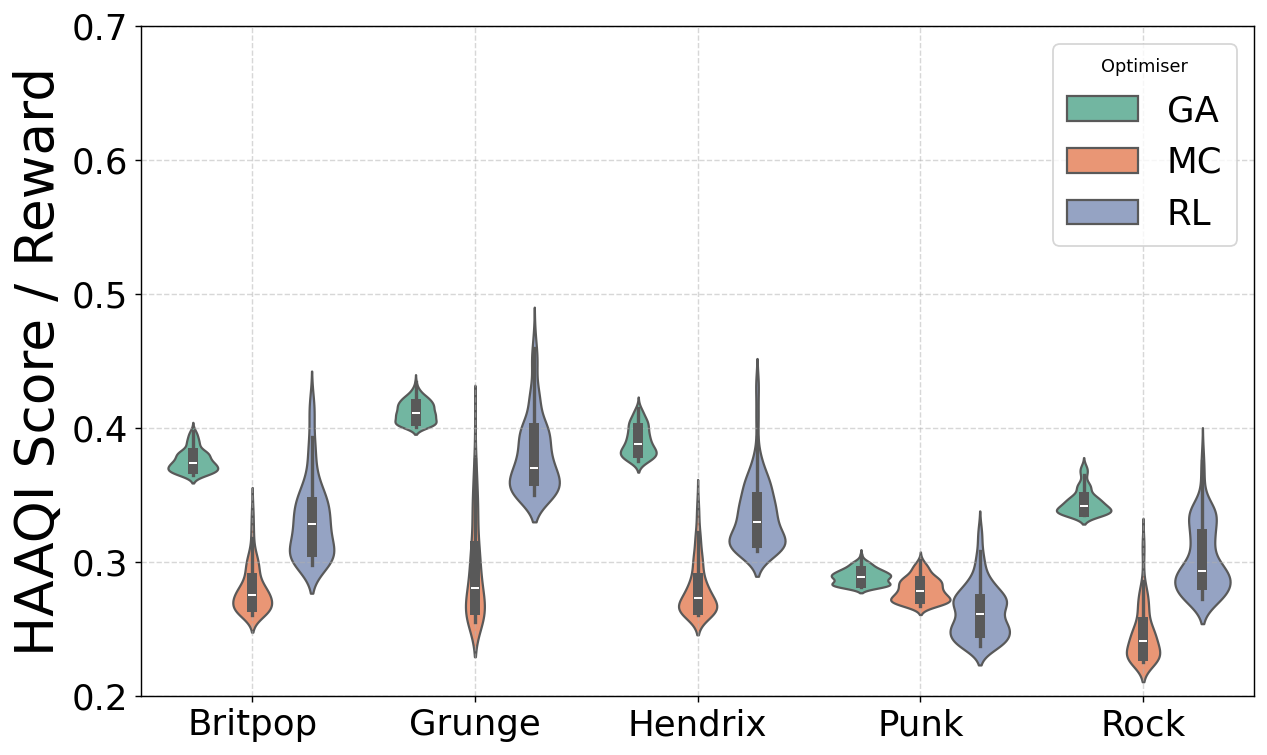

                     mean  median     std     cv
Dataset Optimiser                               
Britpop GA         0.3758  0.3740  0.0084  0.022
        MC         0.2795  0.2750  0.0172  0.062
        RL         0.3319  0.3280  0.0298  0.090
Grunge  GA         0.4123  0.4110  0.0079  0.019
        MC         0.2928  0.2805  0.0353  0.121
        RL         0.3799  0.3700  0.0280  0.074
Hendrix GA         0.3904  0.3880  0.0110  0.028
        MC         0.2797  0.2730  0.0198  0.071
        RL         0.3354  0.3300  0.0261  0.078
Punk    GA         0.2890  0.2890  0.0056  0.019
        MC         0.2793  0.2780  0.0087  0.031
        RL         0.2627  0.2610  0.0194  0.074
Rock    GA         0.3447  0.3420  0.0093  0.027
        MC         0.2460  0.2410  0.0201  0.082
        RL         0.3026  0.2935  0.0254  0.084


In [4]:
# === 4. Optional: keep only top 5% per optimiser/dataset ===
def top_fraction_per_group(df, frac=0.10):
    return df.groupby(["Optimiser", "Dataset"], group_keys=False).apply(
        lambda g: g[g["Value"] >= g["Value"].quantile(1 - frac)]
    )

df_top = top_fraction_per_group(df_all, frac=0.25)

# === 5. Plot grouped boxplots ===
# === 5. Plot grouped boxplots ===
plt.figure(figsize=(10,6),dpi=128)
#sns.boxplot(data=df_top, x="Dataset", y="Value", hue="Optimiser", palette="Set2")
sns.violinplot(data=df_top, x="Dataset", y="Value", hue="Optimiser", palette="Set2")
#plt.title("Top 25% Optimisation Performance Across Datasets and Methods")
plt.ylabel("HAAQI Score / Reward", fontsize=30)
plt.ylim(0.20, 0.70)
plt.xlabel("", fontsize=24)
plt.legend(title="Optimiser",fontsize=20)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.show()



# === 6. Summary stats ===
summary = df_top.groupby(["Dataset", "Optimiser"])["Value"].agg(["mean", "median", "std"]).round(4)
summary["cv"] = (summary["std"] / summary["mean"]).round(3)
print(summary)